<a href="https://colab.research.google.com/github/pop756/Quantum_KAN/blob/EMT/Real_backend.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!git clone -b EMT https://github.com/pop756/Quantum_KAN.git
%cd Quantum_KAN
!pip install -r requirements.txt

Cloning into 'Quantum_KAN'...
remote: Enumerating objects: 894, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 894 (delta 15), reused 22 (delta 1), pack-reused 837
Receiving objects: 100% (894/894), 21.61 MiB | 10.10 MiB/s, done.
Resolving deltas: 100% (133/133), done.
/content/Quantum_KAN
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 11.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 15.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 15.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 9.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.9/249.9 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.8/191.8 kB 11.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import os
import pandas as pd
import re

# Initialize an empty dictionary to store the results
X_dict = {}

# Specify the directory to search for CSV files
directory = "ibm_kyoto"

# Get a list of all CSV files in the specified directory
csv_files = [
    file
    for file in os.listdir(directory)
    if file.endswith(".csv") and file.startswith("ecr_error_")
]

# Regular expression to extract (q_index1, q_index2) from the file name
pattern = re.compile(r"ecr_error_\d+_\((\d+),\s*(\d+)\)_y_pulse.csv")

for file in csv_files:
    match = pattern.match(file)
    if match:
        q_index1 = int(match.group(1))
        q_index2 = int(match.group(2))

        # Read the CSV file into a DataFrame
        df = pd.read_csv(os.path.join(directory, file))

        # Filter rows where the index is greater than 5
        filtered_df = df[df.index > 5]

        # Get the row with the minimum value in ['x0']
        min_x0_row = filtered_df.loc[
            (abs(filtered_df["x1"]) + abs(filtered_df["x0"])).idxmin()
        ]
        print((abs(filtered_df["x1"]) + abs(filtered_df["x0"])).min())
        # Get the ['xval'] value from the row with the minimum ['x0']
        xval = min_x0_row["xval"]

        # Store the result in the dictionary
        X_dict[(q_index1, q_index2)] = xval

0.008
0.0209999999999999
0.0104999999999999
0.015
0.006999999999999999
0.0169999999999998
0.0124999999999999


In [2]:
import qiskit
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
import numpy as np
from qiskit.compiler import transpile
from qiskit_ibm_runtime.options import TwirlingOptions
from qiskit.quantum_info import SparsePauliOp
import uuid
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
def create_trotterized_ising_model_circuit(num_qubits, trotter_steps, time):
    """
    Trotterization을 사용하여 Ising 모델의 양자 서킷을 생성합니다.
    각 Rz 게이트의 파라미터는 Qiskit Parameter로 동적으로 설정됩니다.

    Parameters:
    - num_qubits: 큐비트의 수
    - trotter_steps: Trotterization 단계 수
    - time: 진화 시간

    Returns:
    - QuantumCircuit: 생성된 양자 서킷
    - dict: 서킷 파라미터 사전
    """
    qc = QuantumCircuit(num_qubits)
    delta_t = 1

    # 파라미터 설정
    h_params = [Parameter(f'h_{i}') for i in range(num_qubits)]
    J_params = [[Parameter(f'J_{i}_{j}') for j in range(num_qubits)] for i in range(num_qubits)]

    for _ in range(trotter_steps):
        # 자기 상호작용 항목 추가
        
        for i in range(num_qubits):
            qc.rx(2 * h_params[i] * delta_t, i)

        # 스핀 간 상호작용 항목 추가
        for i in range(num_qubits-1):
            if J_params[i][i+1] != 0:
                qc.cx(i, i+1)
                qc.rz(2 * J_params[i][i+1] * delta_t, i+1)
                qc.cx(i, i+1)

    return qc, h_params, J_params


# ECR 게이트를 제거하는 함수
def remove_ecr_gates(circuit):
    new_circuit = QuantumCircuit(circuit.num_qubits)
    for instr, qargs, cargs in circuit.data:
        if instr.name != 'ecr':
            new_circuit.append(instr, qargs, cargs)
    return new_circuit

# 파라미터 설정
trotter_steps = 3  # Trotterization 단계 수
time = 1.0  # 진화 시간
num_qubits = 8
init_p  =['I' for i in range(num_qubits)]
p_list = []
for i in range(num_qubits):
    temp = init_p.copy()
    temp[i] = 'Z'
    p_list.append(''.join(temp))


hamiltonian = SparsePauliOp.from_list([(p_list[i],1) for i in range(num_qubits)])


In [3]:
# Initialize your account
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator
from qiskit.circuit.library import RealAmplitudes, EfficientSU2

service = QiskitRuntimeService(
    channel="ibm_quantum",
    instance="ibm-q-skku/skku/skku-students",
    token="06f802eeac992c43c4106753d7c5fc31414a13eb7d91c99d67fb49cc50569e5b4b011f20c71b9607a07cb43ecc7044557c699022db91d1685ba4c886d5886854",
)
backend = service.backend(directory)


trotterized_ising_circuit, h_params, J_params = create_trotterized_ising_model_circuit(
    8, trotter_steps, time
)
ansatz = EfficientSU2(8, reps=4)

In [4]:
from functions.Train_ZNE import ZNE_stretch

config = {
    "circ": trotterized_ising_circuit,
    "H": hamiltonian,
    "backend": backend,
    "x_amp_dict": X_dict,
    "error_stretch": 1.0,
    "ecr_stretch": 1.0,
    "l": 0,
    "ZNE_factor": [1, 1.1, 1.2],
}
backend_osaka = service.backend(directory)
zne_osaka = ZNE_stretch(**config)
# zne_osaka.load_data('be24d35b-8b87-4277-a288-7ef6f2f15ede')
# zne_osaka.make_data()

In [5]:
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits
from qiskit_experiments.library.randomized_benchmarking.standard_rb import StandardRB_error

backend_ecr = zne_osaka.ZNE_pulse_ecr(1)
# For simulation
from qiskit_aer import AerSimulator

lengths_2_qubit = np.arange(1, 200,10)
num_samples = 10
seed = 1010
qubits = X_dict.keys()
data_list_ecr_1 = []
# Run a 1-qubit RB experiment on qubits 1, 2 to determine the error-per-gate of 1-qubit gates
for qubit in qubits:
    exp = StandardRB(qubit, lengths_2_qubit, num_samples=num_samples, seed=seed)
    expdata_2q_1_2 = exp.run(backend_ecr).block_for_results()
    data_list_ecr_1.append(expdata_2q_1_2)

C:\Users\pop75\AppData\Roaming\Python\Python311\site-packages\qiskit_ibm_runtime\ibm_backend.py:709: UserWarning: The backend ibm_kyoto is currently paused.
  warnings.warn(f"The backend {self.name} is currently paused.")
base_runtime_job._start_websocket_client:WARNING:2024-07-21 19:58:39,703: An error occurred while streaming results from the server for job ctdqm081zwrg008cfapg:
Traceback (most recent call last):
  File "C:\Users\pop75\AppData\Roaming\Python\Python311\site-packages\qiskit_ibm_runtime\base_runtime_job.py", line 314, in _start_websocket_client
    self._ws_client.job_results()
  File "C:\Users\pop75\AppData\Roaming\Python\Python311\site-packages\qiskit_ibm_runtime\api\clients\runtime_ws.py", line 70, in job_results
    self.stream(url=url, retries=max_retries, backoff_factor=backoff_factor)
  File "C:\Users\pop75\AppData\Roaming\Python\Python311\site-packages\qiskit_ibm_runtime\api\clients\base_websocket_client.py", line 222, in stream
    raise WebsocketError(error_me

In [6]:
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits


backend_ecr = zne_osaka.ZNE_pulse_ecr(1.2)
# For simulation
from qiskit_aer import AerSimulator

lengths_2_qubit = np.arange(1, 200,10)
num_samples = 10
seed = 1010
qubits = X_dict.keys()
data_list_ecr_1_2 = []
# Run a 1-qubit RB experiment on qubits 1, 2 to determine the error-per-gate of 1-qubit gates
for qubit in qubits:
    exp = StandardRB(qubit, lengths_2_qubit, num_samples=num_samples, seed=seed)
    expdata_2q_1_2 = exp.run(backend_ecr).block_for_results()
    data_list_ecr_1_2.append(expdata_2q_1_2)

In [7]:
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits


backend_ecr = zne_osaka.ZNE_pulse_error(1)
# For simulation
from qiskit_aer import AerSimulator

lengths_2_qubit = np.arange(1, 200,10)
num_samples = 10
seed = 1010
qubits = X_dict.keys()
data_list_error_1 = []
# Run a 1-qubit RB experiment on qubits 1, 2 to determine the error-per-gate of 1-qubit gates
for qubit in qubits:
    exp = StandardRB_error(qubit, lengths_2_qubit, num_samples=num_samples, seed=seed)
    expdata_2q_1_2 = exp.run(backend_ecr).block_for_results()
    data_list_error_1.append(expdata_2q_1_2)

In [8]:
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits
from qiskit_experiments.library.randomized_benchmarking.standard_rb import StandardRB_error

backend_ecr = zne_osaka.ZNE_pulse_error(1.2)
# For simulation
from qiskit_aer import AerSimulator

lengths_2_qubit = np.arange(1, 200,10)
num_samples = 10
seed = 1010
qubits = X_dict.keys()
data_list_error_1_2 = []
# Run a 1-qubit RB experiment on qubits 1, 2 to determine the error-per-gate of 1-qubit gates
for qubit in qubits:
    exp = StandardRB_error(qubit, lengths_2_qubit, num_samples=num_samples, seed=seed)
    expdata_2q_1_2 = exp.run(backend_ecr).block_for_results()
    data_list_error_1_2.append(expdata_2q_1_2)

In [9]:
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits
from qiskit_experiments.library.randomized_benchmarking.standard_rb import StandardRB_error

backend_ecr = zne_osaka.ZNE_pulse_error(1.4)
# For simulation
from qiskit_aer import AerSimulator

lengths_2_qubit = np.arange(1, 200,10)
num_samples = 10
seed = 1010
qubits = X_dict.keys()
data_list_error_1_4 = []
# Run a 1-qubit RB experiment on qubits 1, 2 to determine the error-per-gate of 1-qubit gates
for qubit in qubits:
    exp = StandardRB_error(qubit, lengths_2_qubit, num_samples=num_samples, seed=seed)
    expdata_2q_1_2 = exp.run(backend_ecr).block_for_results()
    data_list_error_1_4.append(expdata_2q_1_2)

In [10]:
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits
from qiskit_experiments.library.randomized_benchmarking.standard_rb import StandardRB_error

backend_ecr = zne_osaka.ZNE_pulse_error(1.6)
# For simulation
from qiskit_aer import AerSimulator

lengths_2_qubit = np.arange(1, 200,10)
num_samples = 10
seed = 1010
qubits = X_dict.keys()
data_list_error_1_6 = []
# Run a 1-qubit RB experiment on qubits 1, 2 to determine the error-per-gate of 1-qubit gates
for qubit in qubits:
    exp = StandardRB_error(qubit, lengths_2_qubit, num_samples=num_samples, seed=seed)
    expdata_2q_1_2 = exp.run(backend_ecr).block_for_results()
    data_list_error_1_6.append(expdata_2q_1_2)

jobs and analysis raised exceptions [Experiment ID: e2a4479f-9c81-43e9-b4b3-729fbed9afe2]:Traceback (most recent call last):

  File "C:\Users\pop75\AppData\Roaming\Python\Python311\site-packages\qiskit_ibm_runtime\api\session.py", line 329, in request
    response.raise_for_status()

  File "c:\Users\pop75\anaconda3\envs\EMT\Lib\site-packages\requests\models.py", line 1024, in raise_for_status
    raise HTTPError(http_error_msg, response=self)

requests.exceptions.HTTPError: 404 Client Error: Not Found for url: https://api.quantum.ibm.com/runtime/jobs/ctevk0m1zwrg008cn6cg?exclude_params=true


The above exception was the direct cause of the following exception:


Traceback (most recent call last):

  File "c:\Users\pop75\anaconda3\envs\EMT\Lib\site-packages\qiskit_experiments\framework\experiment_data.py", line 852, in _add_job_data
    job_result = job.result()
                 ^^^^^^^^^^^^

  File "C:\Users\pop75\AppData\Roaming\Python\Python311\site-packages\qiskit_ibm_runtime\runt

KeyboardInterrupt: 

In [ ]:
import os
import pandas as pd
import re

# Initialize an empty dictionary to store the results
X_dict = {}

# Specify the directory to search for CSV files
directory = "ibm_kyoto"

# Get a list of all CSV files in the specified directory
csv_files = [
    file
    for file in os.listdir(directory)
    if file.endswith(".csv") and file.startswith("ecr_error_")
]

# Regular expression to extract (q_index1, q_index2) from the file name
pattern = re.compile(r"ecr_error_\d+_\((\d+),\s*(\d+)\)_y_pulse.csv")

for file in csv_files:
    match = pattern.match(file)
    if match:
        q_index1 = int(match.group(1))
        q_index2 = int(match.group(2))

        # Read the CSV file into a DataFrame
        df = pd.read_csv(os.path.join(directory, file))

        # Filter rows where the index is greater than 5
        filtered_df = df[df.index > 5]

        # Get the row with the minimum value in ['x0']
        min_x0_row = filtered_df.loc[
            (abs(filtered_df["x1"]) + abs(filtered_df["x0"])).idxmin()
        ]
        print((abs(filtered_df["x1"]) + abs(filtered_df["x0"])).min())
        # Get the ['xval'] value from the row with the minimum ['x0']
        xval = min_x0_row["xval"]
        xval = 0
        # Store the result in the dictionary
        X_dict[(q_index1, q_index2)] = xval

In [ ]:
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits
from functions.Train_ZNE import ZNE_stretch

config = {
    "circ": trotterized_ising_circuit,
    "H": hamiltonian,
    "backend": backend,
    "x_amp_dict": X_dict,
    "error_stretch": 1.0,
    "ecr_stretch": 1.0,
    "l": 0,
    "ZNE_factor": [1, 1.1, 1.2],
}
backend_osaka = service.backend(directory)
zne_osaka = ZNE_stretch(**config)

backend_ecr = zne_osaka.ZNE_pulse_error(1)
# For simulation
from qiskit_aer import AerSimulator

lengths_2_qubit = np.arange(1, 200,10)
num_samples = 10
seed = 1010
qubits = X_dict.keys()
data_list_error_1_no_X = []
# Run a 1-qubit RB experiment on qubits 1, 2 to determine the error-per-gate of 1-qubit gates
for qubit in qubits:
    exp = StandardRB_error(qubit, lengths_2_qubit, num_samples=num_samples, seed=seed)
    expdata_2q_1_2 = exp.run(backend_ecr).block_for_results()
    data_list_error_1_no_X.append(expdata_2q_1_2)

In [ ]:
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits
from functions.Train_ZNE import ZNE_stretch

config = {
    "circ": trotterized_ising_circuit,
    "H": hamiltonian,
    "backend": backend,
    "x_amp_dict": X_dict,
    "error_stretch": 1.0,
    "ecr_stretch": 1.0,
    "l": 0,
    "ZNE_factor": [1, 1.1, 1.2],
}
backend_osaka = service.backend(directory)
zne_osaka = ZNE_stretch(**config)

backend_ecr = zne_osaka.ZNE_pulse_error(1.2)
# For simulation
from qiskit_aer import AerSimulator

lengths_2_qubit = np.arange(1, 200,10)
num_samples = 10
seed = 1010
qubits = X_dict.keys()
data_list_error_1_2_no_X = []
# Run a 1-qubit RB experiment on qubits 1, 2 to determine the error-per-gate of 1-qubit gates
for qubit in qubits:
    exp = StandardRB_error(qubit, lengths_2_qubit, num_samples=num_samples, seed=seed)
    expdata_2q_1_2 = exp.run(backend_ecr).block_for_results()
    data_list_error_1_2_no_X.append(expdata_2q_1_2)

In [ ]:
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits


backend_ecr = zne_osaka.ZNE_pulse_error(1)
# For simulation
from qiskit_aer import AerSimulator

lengths_2_qubit = np.arange(1, 200,10)
num_samples = 10
seed = 1010
qubits = X_dict.keys()
data_list_error_1_no_X = []
# Run a 1-qubit RB experiment on qubits 1, 2 to determine the error-per-gate of 1-qubit gates
for qubit in qubits:
    exp = StandardRB_error(qubit, lengths_2_qubit, num_samples=num_samples, seed=seed)
    expdata_2q_1_2 = exp.run(backend_ecr).block_for_results()
    data_list_error_1_no_X.append(expdata_2q_1_2)

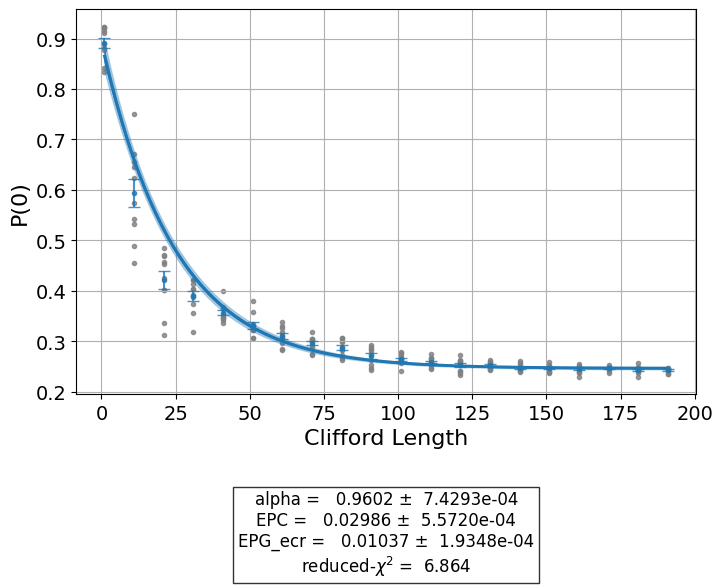

In [13]:
data_list_error_1_4[0].figure(0)

In [1]:
import numpy as np
from scipy.linalg import expm
main_rate = 1/2
sub_rate = 0.1
# Example matrix
A = np.array([[0, 1], [1, 0]])
B = np.array([[0, -1j], [1j, 0]])
C = np.array([[1, 0], [0, -1]])
# Compute the matrix exponential
exp_A = expm(1j*A*main_rate*np.pi/2+1j*B*np.pi/2*sub_rate+C*1j*sub_rate)
exp_B = expm(1j*A*main_rate*np.pi/2)
exp_C = expm(1j*B*1)
print("Matrix A:")
print(A)

print("Exponential of matrix A:")
print(exp_A)
print(exp_B)
print(exp_C)
np.sum(abs(exp_A-exp_B))

Matrix A:
[[0 1]
 [1 0]]
Exponential of matrix A:
[[ 0.69154501+0.08948956j  0.14056987+0.70284936j]
 [-0.14056987+0.70284936j  0.69154501-0.08948956j]]
[[0.70710678+0.j         0.        +0.70710678j]
 [0.        +0.70710678j 0.70710678+0.j        ]]
[[ 0.54030231+0.j  0.84147098+0.j]
 [-0.84147098+0.j  0.54030231+0.j]]


0.46293373842545843

In [68]:
import numpy as np

def remove_global_phase(matrix):
    """Remove the global phase from a complex matrix by normalizing the first element to 1."""
    phase = np.angle(matrix[0, 0])
    return matrix * np.exp(-1j * phase)

def complex_matrix_l2_distance(A, B):
    """Compute the L2 distance between two complex matrices, ignoring global phase."""
    A_normalized = remove_global_phase(A)
    B_normalized = remove_global_phase(B)
    return np.linalg.norm(A_normalized - B_normalized, 'fro')

# Example usage
A = np.array([[1+1j, 2+2j], [3+3j, 4+4j]])
A = A*1j
B = np.array([[2+2j, 3+3j], [4+4j, 5+5j]])

distance = complex_matrix_l2_distance(A, B)
print(f"The L2 distance between A and B, ignoring global phase, is: {distance}")


The L2 distance between A and B, ignoring global phase, is: 2.828427124746191


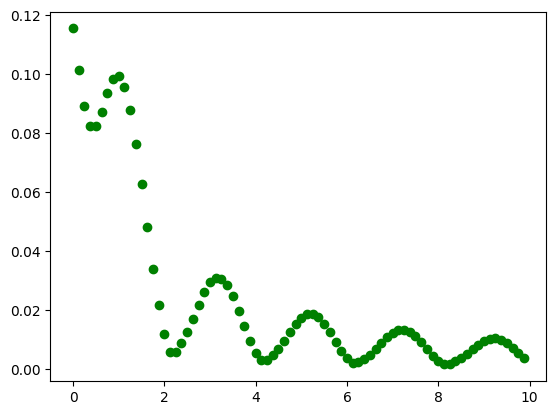

In [185]:
from matplotlib import pyplot as plt
import numpy as np

x_data = np.array([0.125*i for i in range(0,80)])
# Example matrix
X = np.array([[0, 1], [1, 0]])
Y = np.array([[0, -1j], [1j, 0]])
Z = np.array([[1, 0], [0, -1]])
I = np.array([[1,0],[0,1]])
y_data = []
y_data_2 = []
sub_rate = 0.1


Z_X = np.kron(Z,X)
I_X = np.kron(I,X)
I_Z = np.kron(I,Z)
Z_Y = np.kron(Z,Y)
I_Y = np.kron(I,Y)
X_I = np.kron(X,I)
Z_I = np.kron(Z,I)
I_I = np.kron(I,I)
Z_Z = np.kron(Z,Z)
X_Z = np.kron(X,Z)

def CR_4(x_data,rate):
    y_data = []
    for x in x_data: 
        hamiltonian_2 = (Z_X/4+I_X*x*2/rate+I_Z*0.1+I_Y*0.01+Z_Y*sub_rate+Z_I+Z_Z*0.1)/2*np.pi/2*rate
        CR_real_1 = expm(1j*hamiltonian_2)
        CR_ideal = expm(1j*I_I)
        
        result_ideal = abs(CR_ideal)
        result_real = CR_real_1@I_Z@CR_real_1@I_Z@I_X@X_I@CR_real_1@I_Z@CR_real_1@I_Z@I_X@X_I
        error = np.sum(abs(result_ideal-result_real))
        y_data.append(error)
    return y_data

def CR_4(x_data,rate):
    y_data = []
    for x in x_data: 
        hamiltonian_2 = (Z_X/4+I_X*x*2/rate+I_Z*0.1+I_Y*0.01+Z_Y*sub_rate+Z_I+Z_Z*0.1)/2*np.pi/2*rate
        CR_real_1 = expm(1j*hamiltonian_2)
        CR_ideal = expm(1j*I_I)
        
        result_ideal = abs(CR_ideal)
        result_real = CR_real_1@I_Z@CR_real_1@I_Z@I_X@X_I@CR_real_1@I_Z@CR_real_1@I_Z@I_X@X_I
        error = np.sum(abs(result_ideal-result_real))
        y_data.append(error)
    return y_data

def CR_2(x_data):
    y_data = []
    for x in x_data: 
        hamiltonian_2 = (Z_X/4+I_X*x+I_Z*0.1+I_Y*0.1+Z_Y*sub_rate+Z_I+Z_Z*0.1)*1*np.pi/2
        hamiltonian_3 = (Z_X/4-I_X*(x-1/4)+I_Z*0.1+I_Y*0.1+Z_Y*sub_rate+Z_I+Z_Z*0.1)*1*np.pi/2
        hamiltonian_main_2 = (Z_X/4+I_X*x+Z_I)*np.pi/2
        main_rate = x
        CR_real_1 = expm(1j*hamiltonian_2)
        CR_real_2 = expm(1j*hamiltonian_3)
        CR_ideal = expm(1j*I_I)
        
        result_ideal = abs(CR_ideal)
        result_real = CR_real_1@X_I@CR_real_2@X_I
        error = np.sum(abs(result_ideal-result_real))
        y_data.append(error)
    return y_data

def ECR(x_data):
    y_data = []
    for x in x_data: 
        hamiltonian_2 = (Z_X/4+Z_Y*0.01+I_X*x-Z_Z*0.01+I_Z*0.01)*np.pi/2
        CR_real_1 = expm(1j*hamiltonian_2)
        CR_ideal = expm(1j*Z_X*np.pi/4)
        
        result_ideal = CR_ideal
        #result_real = CR_real_1
        result_real = CR_real_1@X_Z@CR_real_1@X_Z
        #result_real = CR_real_1@CR_real_2
        error = complex_matrix_l2_distance(result_ideal,result_real)
        y_data.append(error)
    return y_data
    
    


def test(x_data):
    y_data = []
    for x in x_data: 
        hamiltonian_2 = (X*x+0.002*Z)*np.pi/2
        CR_real_1 = expm(1j*hamiltonian_2)
        CR_ideal = expm(1j*X*x*np.pi/2)
        result_ideal = CR_ideal
        #result_real = CR_real_1
        result_real = CR_real_1
        #result_real = CR_real_1@CR_real_2
        error = np.sum(abs(result_ideal-result_real))
        y_data.append(error)
    return y_data
#y_data_2 = CR_4(x_data,2)
#y_data_4 = CR_2(x_data)
y_data_6 = ECR(x_data)
#plt.plot(x_data,y_data_2,'bo')
#plt.plot(x_data,y_data_4,'ro')
plt.plot(x_data,y_data_6,'go')


In [183]:
hamiltonian_2 = (Z_X/4+I_X*2.25+Z_I+Z_Z*0.01-I_Z*0.01)*np.pi/2
hamiltonian_3 = (Z_X/4+I_X*2.25+Z_I+Z_Z*0.01-I_Z*0.01)*np.pi/2
CR_real_1 = expm(1j*hamiltonian_2)
CR_real_2 = expm(1j*hamiltonian_3)
CR_ideal = expm(1j*Z_X*np.pi/4)

result_ideal = CR_ideal
#result_real = CR_real_1
result_real = CR_real_1@X_Z@CR_real_2@X_Z
#result_real = CR_real_1@CR_real_2
error = complex_matrix_l2_distance(result_ideal,result_real)
print(error)

0.0003141671121224925


In [ ]:
0.009797635851305097

In [ ]:
0.0003141671121224925

(0.0, 0.01)

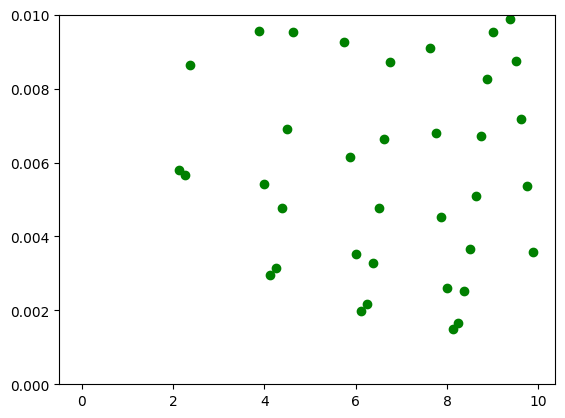

In [186]:
plt.plot(x_data,y_data_6,'go')
plt.ylim(0,0.01)

(0.0, 0.1)

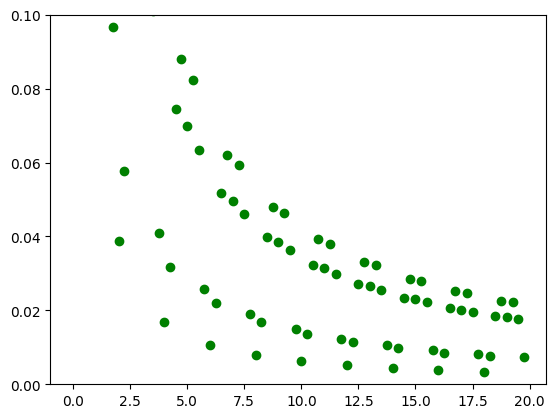

In [28]:
plt.plot(x_data,y_data_6,'go')
plt.ylim(0,0.1)

(0.0, 0.1)

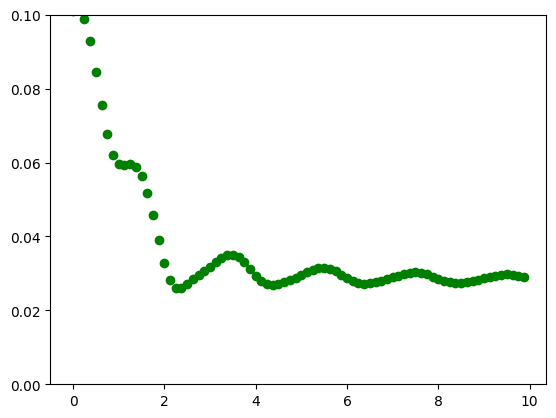

In [178]:
plt.plot(x_data,y_data_6,'go')
plt.ylim(0,0.1)

In [173]:
y_data_6[0]/y_data_6[8]

12.665195341401407

In [169]:
y_data_6[0]/y_data_6[8+8*2]

57.81944195759906

In [5]:
H = Z_X*np.pi/4+I_Y*0.001
H_minus = 1j*Z_X*np.pi/4-1j*I_Y*0.001
print(np.sum(abs(expm(2*1j*Z_X*np.pi/4)-expm(1j*H)@I_X@expm(1j*H)@I_X)))
print(np.sum(abs(expm(2*1j*Z_X*np.pi/4)-expm(1j*H)@expm(H_minus))))
print(np.sum(abs(expm(2*1j*Z_X*np.pi/4)-expm(1j*H)@expm(1j*H))))

0.005096198874400106
0.005096198874399884
0.005098048038908697


In [6]:
def compare(x_data):
    y_data = []
    for x in x_data: 
        hamiltonian_2 = (I_X*x+0.05*I_Z+0.05*I_Y)*np.pi/2
        CR_real_1 = I_Y@I_Y
        for i in range(x):
            CR_real_1 @= expm(1j*I_X*np.pi/2)@expm(1j*0.05/x*(I_Z)*np.pi/2)@expm(1j*0.05/x*(I_Y)*np.pi/2)
        CR_ideal = expm(1j*hamiltonian_2)
        #result_real = CR_real_1@CR_real_2
        error = np.sum(abs(CR_ideal-CR_real_1))


        y_data.append(error)
    return y_data

In [65]:
from scipy.optimize import minimize

def find_mat(variable,H):
    print(variable)
    a,b,c = variable[0],variable[1],variable[2]
    result = np.sum(abs(H-expm(1j*(a*X))@expm(1j*(b*Y+c*Z))))
    print(result)
    return result

In [59]:
X@expm(1j*0.1*Y)@X@expm(1j*0.1*Y)

array([[1.0000000e+00+0.j, 3.7542067e-18+0.j],
       [3.7542067e-18+0.j, 1.0000000e+00+0.j]])

In [87]:
np.pi/2-np.sqrt((np.pi/2)**2 + (0.2*np.sqrt(2))**2)

-0.02526166095878768

In [88]:
0.2/(np.pi/2)

0.12732395447351627

In [85]:
H=expm(-1j*X*np.pi/2)@expm(1j*X*np.pi/2+1j*Z*0.2+1j*Y*0.2)
x0 = np.array([1,1,1])
minimize(find_mat,x0,args=(H))

[1. 1. 1.]
4.111365298438459
[1.00000001 1.         1.        ]
4.111365306159511
[1.         1.00000001 1.        ]
4.111365312629056
[1.         1.         1.00000001]
4.111365308814918
[0.59385072 0.25353429 0.4541688 ]
2.0286055579341538
[0.59385074 0.25353429 0.4541688 ]
2.0286055855392666
[0.59385072 0.2535343  0.4541688 ]
2.028605572685654
[0.59385072 0.25353429 0.45416881]
2.0286055821225935
[-1.03074639 -2.73232857 -1.72915602]
4.668259366551483
[-1.03074637 -2.73232857 -1.72915602]
4.668259377304686
[-1.03074639 -2.73232855 -1.72915602]
4.668259370285051
[-1.03074639 -2.73232857 -1.72915601]
4.668259369060721
[ 0.27454031 -0.33332943  0.02504188]
0.7405126745219349
[ 0.27454032 -0.33332943  0.02504188]
0.7405126996311868
[ 0.27454031 -0.33332942  0.02504188]
0.740512651785199
[ 0.27454031 -0.33332943  0.02504189]
0.7405126652873553
[-1.28886553 -0.33405374 -0.28370917]
3.67426591424545
[-1.28886551 -0.33405374 -0.28370917]
3.6742658852051875
[-1.28886553 -0.33405372 -0.283709

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 3.249363204676975e-08
        x: [ 2.567e-02 -1.291e-01  1.227e-01]
      nit: 31
      jac: [ 2.790e-01 -9.212e-02 -4.937e-02]
 hess_inv: [[ 1.371e-08 -3.696e-09 -2.124e-09]
            [-3.696e-09  5.567e-09  7.624e-10]
            [-2.124e-09  7.624e-10  4.277e-09]]
     nfev: 356
     njev: 86

In [264]:
np.sum(abs(expm(1j*I_X*np.pi/2-1j*I_Z*0.005)-expm(1j*I_X*np.pi/2)))

0.01275263494243344

In [254]:

start = 1/2*commute(1j*I_X*np.pi/4,0.01*I_Z)
print(np.sum(abs(start)))
for i in range(100):
    start =  1/2*commute(1j*I_X*np.pi/4,start )


print(np.sum(abs(start)))

0.031415926535897934
1.0142336358537202e-12


In [220]:
Y@Y

array([[1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]])

In [245]:
y_data[1]/y_data[9]

5.579608616150398

In [265]:
y_data[1]

0.005154274374363102

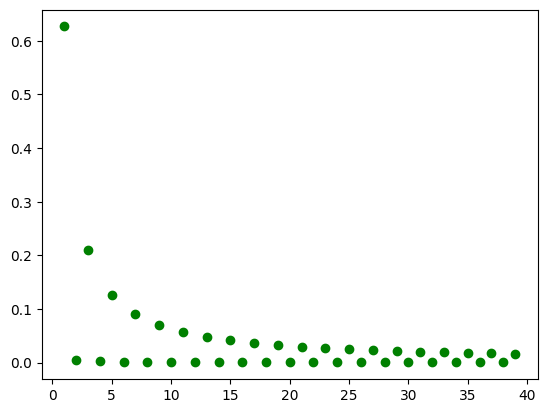

In [239]:
y_data = compare(x_data)
plt.plot(x_data,y_data,'go')

In [124]:
0.00020119357095094205// 2.2348079382299017e-05

9.0

In [71]:
A = I_X
B = I_Z*0.008-Z_Y*0.008+Z_Z*0.002
def distance(A,B):
    return np.sum(abs(commute(A,B)))

def commute(A,B):
    return A@B - B@A

main = distance(A,B)

In [72]:
main

0.128

C:\Users\pop75\AppData\Local\Temp\ipykernel_33700\512557462.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


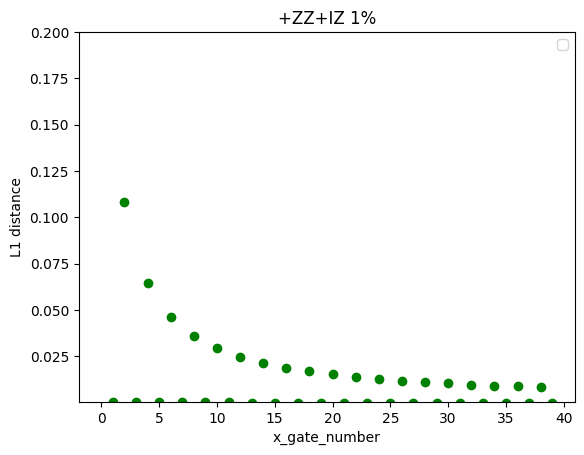

In [38]:
plt.plot(x_data,y_data_6,'go')
plt.xlabel('x_gate_number')
plt.ylabel('L1 distance')
plt.title('+ZZ+IZ 1%')
plt.ylim(0.0005,0.2)
plt.legend()

C:\Users\pop75\AppData\Local\Temp\ipykernel_33700\1393485524.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


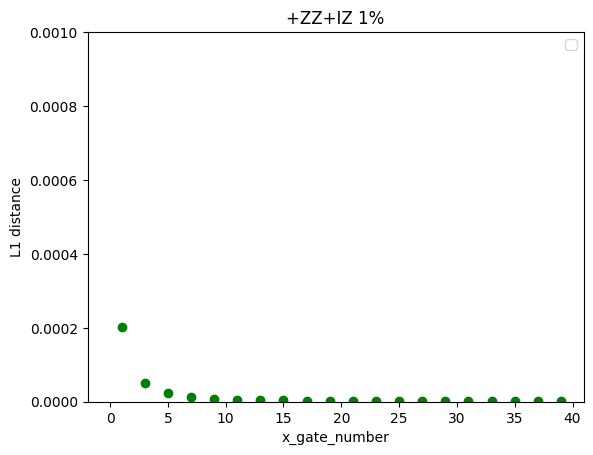

In [53]:
plt.plot(x_data,y_data_6,'go')
plt.xlabel('x_gate_number')
plt.ylabel('L1 distance')
plt.title('+ZZ+IZ 1%')
plt.ylim(0,0.001)
plt.legend()

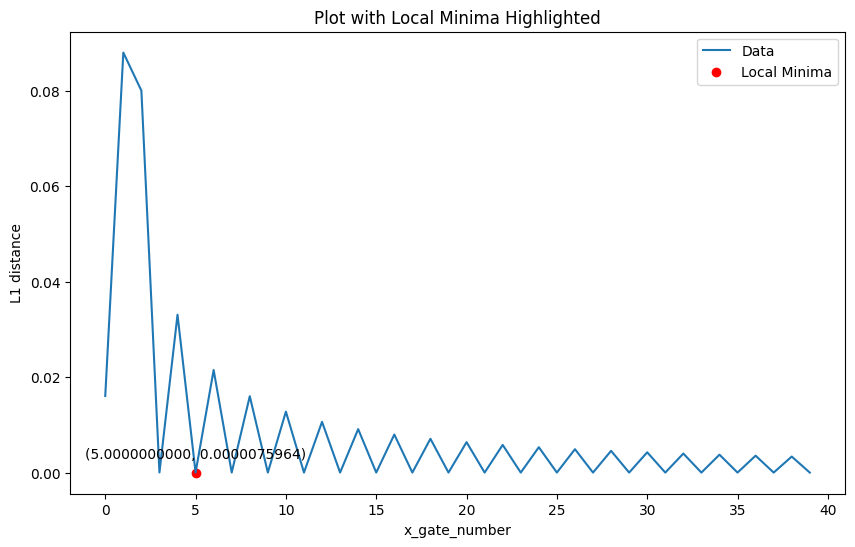

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import argrelextrema

# 데이터 생성 (예시)
x = x_data
y = np.array(y_data_6)

# 국소 최소값 찾기
local_min_indices = argrelextrema(y, np.less,order=5)[0]

# 플롯 생성
plt.figure(figsize=(10, 6))
plt.plot(x, y,label='Data')
plt.scatter(x[local_min_indices], y[local_min_indices], color='red', label='Local Minima')

# 강조된 국소 최소값에 대한 레이블 추가
for i in local_min_indices:
    plt.annotate(f'({x[i]:.10f}, {y[i]:.10f})', (x[i], y[i]), textcoords="offset points", xytext=(0,10), ha='center')

# 레이블 및 범례 추가
plt.xlabel('x_gate_number')
plt.ylabel('L1 distance')
plt.title('Plot with Local Minima Highlighted')
plt.legend()
plt.show()

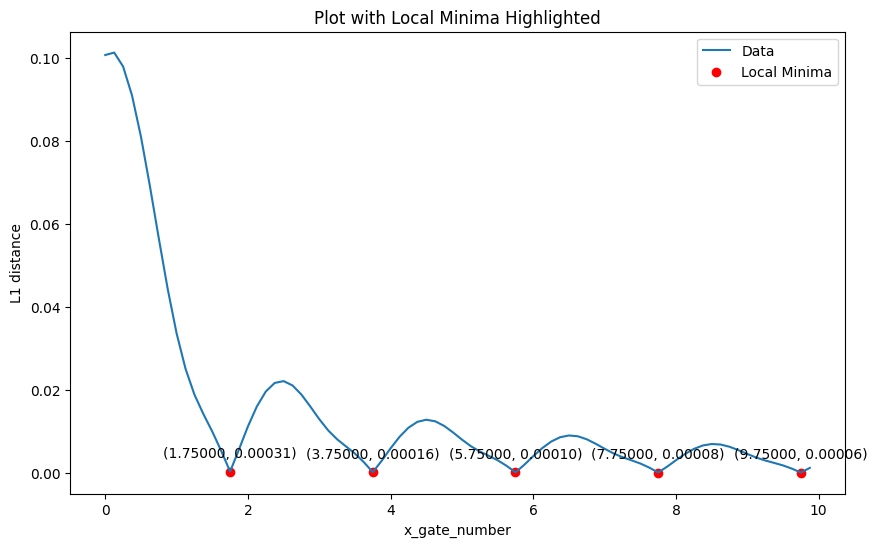

In [130]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import argrelextrema

# 데이터 생성 (예시)
x = x_data
y = np.array(y_data_6)

# 국소 최소값 찾기
local_min_indices = argrelextrema(y, np.less,order=5)[0]

# 플롯 생성
plt.figure(figsize=(10, 6))
plt.plot(x, y,label='Data')
plt.scatter(x[local_min_indices], y[local_min_indices], color='red', label='Local Minima')

# 강조된 국소 최소값에 대한 레이블 추가
for i in local_min_indices:
    plt.annotate(f'({x[i]:.5f}, {y[i]:.5f})', (x[i], y[i]), textcoords="offset points", xytext=(0,10), ha='center')

# 레이블 및 범례 추가
plt.xlabel('x_gate_number')
plt.ylabel('L1 distance')
plt.title('Plot with Local Minima Highlighted')
plt.legend()
plt.show()


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39])

Fitted parameter a: 0.06574150895502373


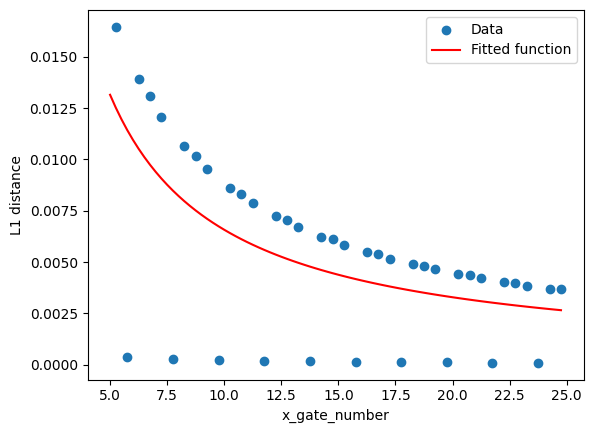

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

x_data_odd= x_data[[2*i+1 for i in range(len(x_data)//2)]]
y_data_odd= np.array(y_data_6)[[2*i+1 for i in range(len(y_data_6)//2)]]
# 모델 함수 정의
def model(x, a):
    return a / x

# 비선형 피팅 수행
params, params_covariance = curve_fit(model, x_data_odd, y_data_odd, p0=[1])

# 피팅 결과 출력
print("Fitted parameter a:", params[0])

# 데이터와 피팅된 곡선 시각화
plt.scatter(x_data_odd, y_data_odd, label='Data')
plt.plot(x_data, model(x_data, params[0]), label='Fitted function', color='red')
plt.xlabel('x_gate_number')
plt.ylabel('L1 distance')
plt.legend()
plt.show()

C:\Users\pop75\AppData\Local\Temp\ipykernel_22580\1847212386.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


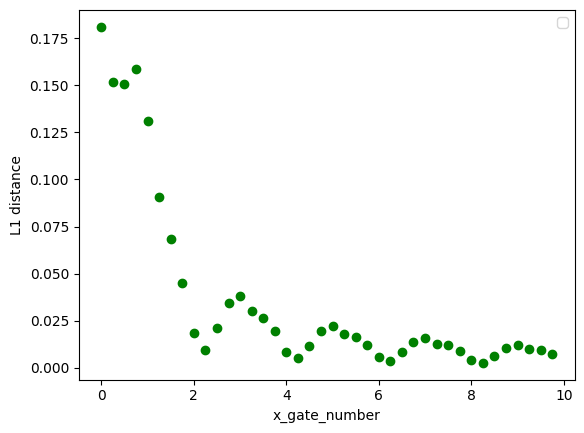

In [114]:
plt.plot(x_data,y_data_6,'go')
plt.xlabel('x_gate_number')
plt.ylabel('L1 distance')
plt.legend()


In [85]:
x_data[np.argmin(y_data_6)]

23.5

C:\Users\pop75\AppData\Local\Temp\ipykernel_22580\1408466096.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


(0.0, 0.001)

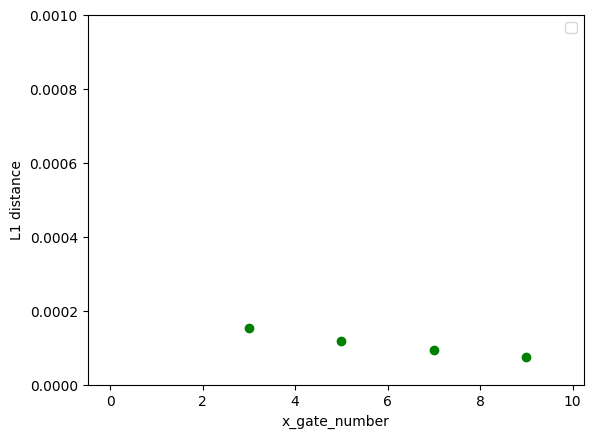

In [92]:
plt.plot(x_data,y_data_6,'go')
plt.xlabel('x_gate_number')
plt.ylabel('L1 distance')
plt.legend()

plt.ylim(0,0.001)

C:\Users\pop75\AppData\Local\Temp\ipykernel_22580\1656548406.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


(0.0, 0.03)

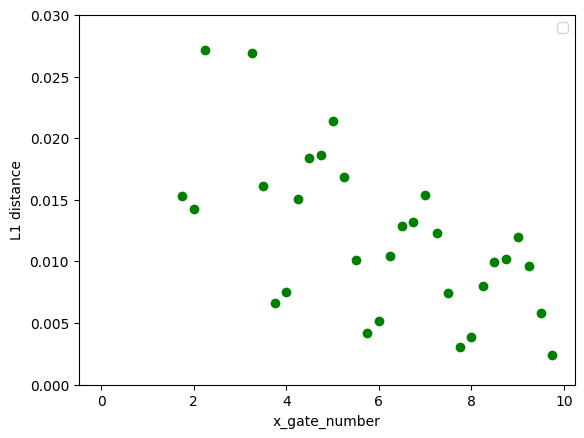

In [95]:
plt.plot(x_data,y_data_6,'go')
plt.xlabel('x_gate_number')
plt.ylabel('L1 distance')
plt.legend()

plt.ylim(0,0.03)


C:\Users\pop75\AppData\Local\Temp\ipykernel_22580\1408466096.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


(0.0, 0.001)

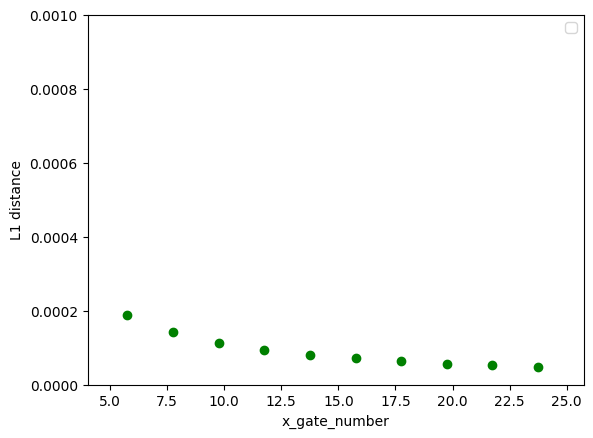

In [52]:
plt.plot(x_data,y_data_6,'go')
plt.xlabel('x_gate_number')
plt.ylabel('L1 distance')
plt.legend()

plt.ylim(0,0.001)

C:\Users\pop75\AppData\Local\Temp\ipykernel_22580\1408466096.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


(0.0, 0.001)

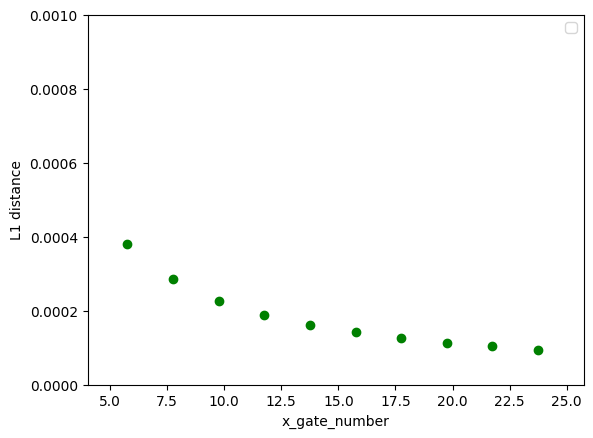

In [50]:
plt.plot(x_data,y_data_6,'go')
plt.xlabel('x_gate_number')
plt.ylabel('L1 distance')
plt.legend()

plt.ylim(0,0.001)

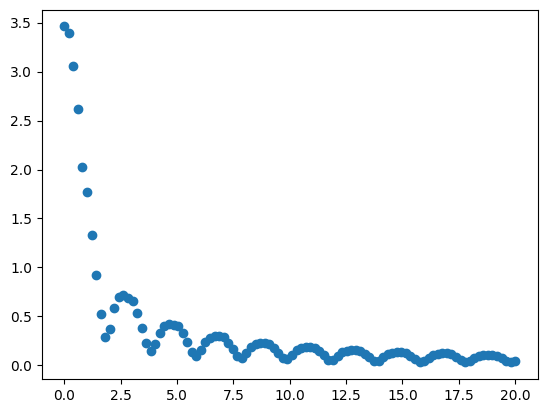

In [343]:
plt.plot(x_data,y_data_4,'o')

In [335]:
0.0052186273740082055*60

0.31311764244049234

(0.0, 0.2)

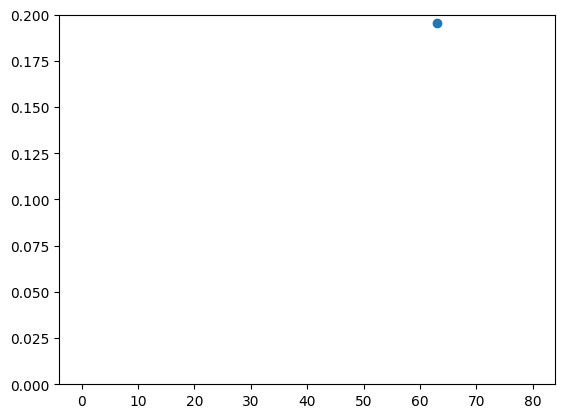

In [336]:
plt.plot(x_data,y_data_2,'o')
plt.ylim(0,0.2)
#plt.plot(x_data,y_data_4,'o')

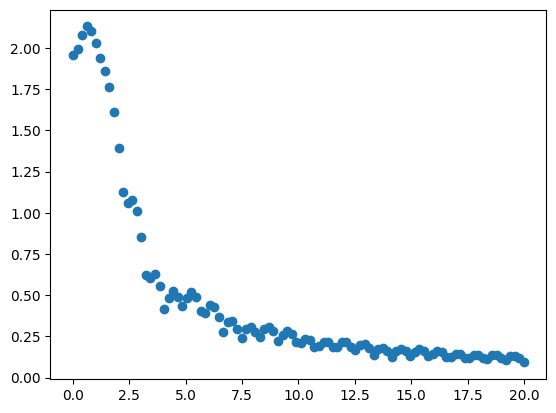

In [289]:
plt.plot(x_data,y_data_2,'o')
#plt.plot(x_data,y_data_4,'o')

(0.0, 0.2)

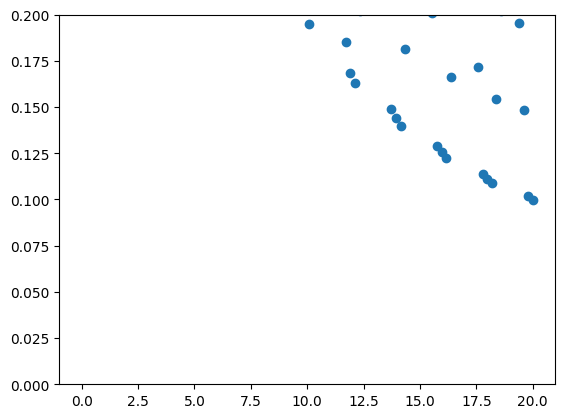

In [278]:
##data 4 CR

plt.plot(x_data,y_data,'o')
plt.ylim(0,0.2)


([<matplotlib.axis.XTick at 0x14e181be910>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17'),
  Text(18, 0, '18'),
  Text(19, 0, '19'),
  Text(20, 0, '20'),
  Text(21, 0, '21'),
  Text(22, 0, '22'),
  Text(23, 0, '23'),
  Text(24, 0, '24'),
  Text(25, 0, '25'),
  Text(26, 0, '26'),
  Text(27, 0, '27'),
  Text(28, 0, '28'),
  Text(29, 0, '29'),
  Text(30, 0, '30'),
  Text(31, 0, '31'),
  Text(32, 0, '32'),
  Text(33, 0, '33'),
  Text(34, 0, '34'),
  Text(35, 0, '35'),
  Text(36, 0, '36'),
  Text(37, 0, '37'),
  Text(38, 0, '38'),
  Text(39, 0, '39')])

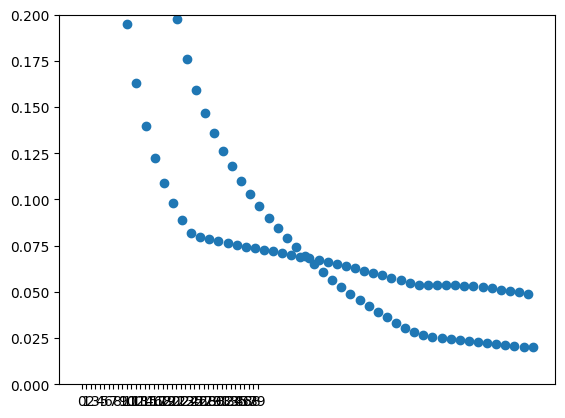

In [273]:
##data 2 CR

plt.plot(x_data,y_data,'o')
plt.ylim(0,0.2)


In [218]:
abs(CR_ideal)

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

In [216]:
I_I

array([[1, 0, 0, 0],
       [0, 1, 0, 0],
       [0, 0, 1, 0],
       [0, 0, 0, 1]])

(0.0, 0.01)

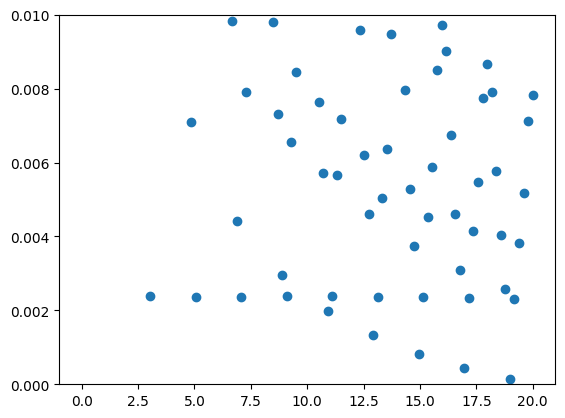

In [208]:
plt.plot(x_data,y_data,'o')
plt.ylim(0,0.01)

In [210]:
np.sum(abs(expm(1j*Z_X*np.pi)-result_real))

0.007819969045524653

In [212]:
np.sum(abs(expm(1j*Z_X*np.pi/4)-result_real))

0.001977786478406853

(0.0, 0.1)

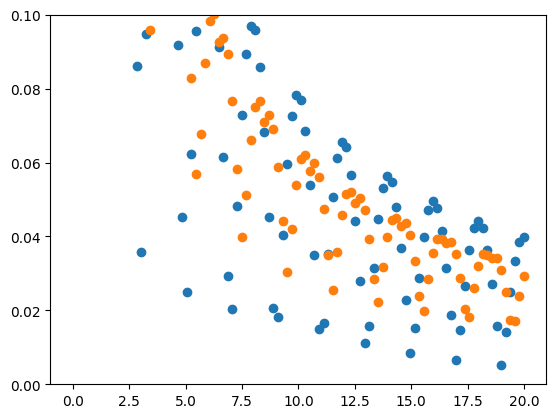

In [142]:
plt.plot(x_data,y_data,'o')
plt.plot(x_data,y_data_2,'o')
plt.ylim(0,0.1)

([<matplotlib.axis.XTick at 0x14d901ade90>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17'),
  Text(18, 0, '18'),
  Text(19, 0, '19')])

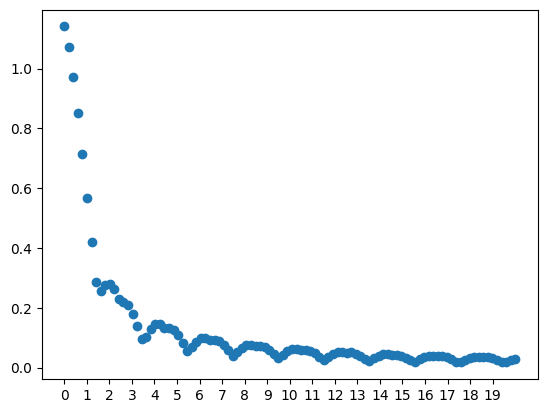

In [133]:
plt.plot(x_data,y_data,'o')
plt.xticks(np.arange(0, 20, 1))

In [24]:
np.sum(abs(exp_A-exp_B))

0.08937420874565039

In [ ]:
def remove_ecr_gates(circuit):
    new_circuit = QuantumCircuit(circuit.num_qubits)
    for instr, qargs, cargs in circuit.data:

        if instr.name == "measure":
            continue

        elif instr.name == "cx" and qargs[0]._index == 0:
            new_circuit.x(1)

        elif instr.name != "cx":
            new_circuit.append(instr, qargs, cargs)
    return new_circuit

In [ ]:
def get_forward(circuit):
    new_circuit = QuantumCircuit(circuit.num_qubits)
    index = 0
    for instr, qargs, cargs in circuit.data:
        if instr.name == "barrier":
            index += 1
            continue
    index_forward = 0
    for instr, qargs, cargs in circuit.data:
        if (index - 1) == index_forward:
            break
        new_circuit.append(instr, qargs, cargs)
        if instr.name == "barrier":
            index_forward += 1
    return new_circuit


def get_forward_inverse(circuit):
    circuit_forward = get_forward(circuit)
    circuit_reverse = circuit_forward.inverse()
    circuit_forward.append(circuit_reverse, [0, 1])
    return circuit_forward

In [ ]:
import qiskit.circuit.library as circuits
from qiskit.primitives import Sampler

# from functions.Train_ZNE import remove_ecr_gates


exp = StandardRB_error(physical_qubits=(0, 1), lengths=[5], num_samples=5, seed=52)
c = exp.circuits()[2]

sampler = Sampler()
#c = get_forward_inverse(c)
#c.measure_all()
job = sampler.run(c)
job.result()

SamplerResult(quasi_dists=[{0: 0.999999999999992}], metadata=[{}])

In [ ]:
from qiskit import transpile
from qiskit import QuantumCircuit

c = remove_ecr_gates(c)
c = transpile(c, basis_gates=["y", "x", "h", "s", "z", "cx"])



c.measure_all()

In [ ]:
sampler = Sampler()
job = sampler.run(c)
job.result()

SamplerResult(quasi_dists=[{0: 0.999999999999994}], metadata=[{}])